In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
from google.colab import files
uploaded = files.upload()


Saving Cust_Segmentation.csv to Cust_Segmentation.csv


In [3]:
df = pd.read_csv("Cust_Segmentation.csv")
df.head()


,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


In [4]:
df.info()
df.describe()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      850 non-null    int64  
 1   Age              850 non-null    int64  
 2   Edu              850 non-null    int64  
 3   Years Employed   850 non-null    int64  
 4   Income           850 non-null    int64  
 5   Card Debt        850 non-null    float64
 6   Other Debt       850 non-null    float64
 7   Defaulted        700 non-null    float64
 8   Address          850 non-null    object 
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 66.5+ KB


,0
Customer Id,0
Age,0
Edu,0
Years Employed,0
Income,0
Card Debt,0
Other Debt,0
Defaulted,150
Address,0
DebtIncomeRatio,0


In [5]:
# Make a copy
data = df.copy()

# Example: Defaulted should be imputed with mode if missing
if "Defaulted" in data.columns:
    data["Defaulted"] = data["Defaulted"].fillna(data["Defaulted"].mode()[0])

# Fill numeric missing values with median
numeric_cols = data.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if data[col].isna().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

data.isna().sum()


,0
Customer Id,0
Age,0
Edu,0
Years Employed,0
Income,0
Card Debt,0
Other Debt,0
Defaulted,0
Address,0
DebtIncomeRatio,0


In [6]:
# Drop common non clustering fields if they exist
drop_candidates = ["Customer Id", "CustomerID", "ID", "Address", "City", "State", "Zip", "PostalCode"]
to_drop = [c for c in drop_candidates if c in data.columns]
data = data.drop(columns=to_drop, errors="ignore")

data.head()


,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,0.0,6.3
1,47,1,26,100,4.582,8.218,0.0,12.8
2,33,2,10,57,6.111,5.802,1.0,20.9
3,29,2,4,19,0.681,0.516,0.0,6.3
4,47,1,31,253,9.308,8.908,0.0,7.2


In [7]:
features = [
    "Age", "Edu", "Years Employed", "Income",
    "Card Debt", "Other Debt", "Defaulted", "DebtIncomeRatio"
]

X = data[features].copy()
X.head()


,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,0.0,6.3
1,47,1,26,100,4.582,8.218,0.0,12.8
2,33,2,10,57,6.111,5.802,1.0,20.9
3,29,2,4,19,0.681,0.516,0.0,6.3
4,47,1,31,253,9.308,8.908,0.0,7.2


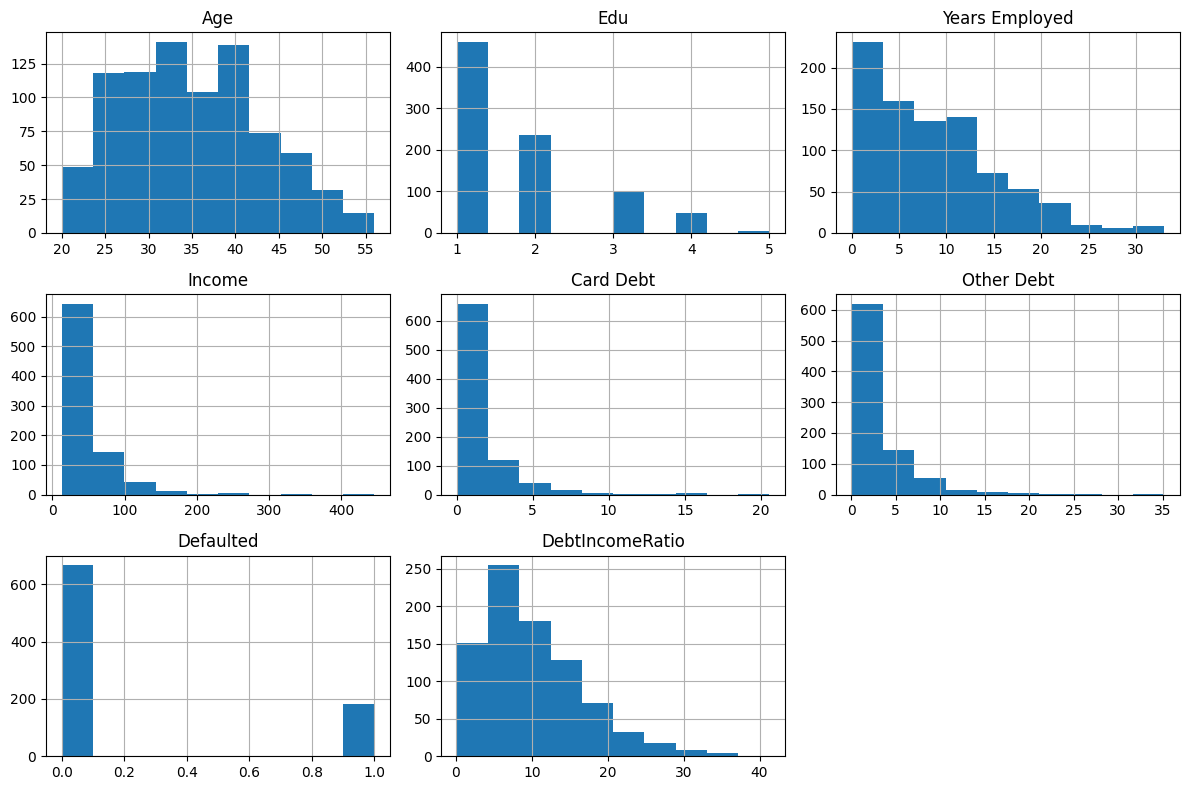

In [8]:
X.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


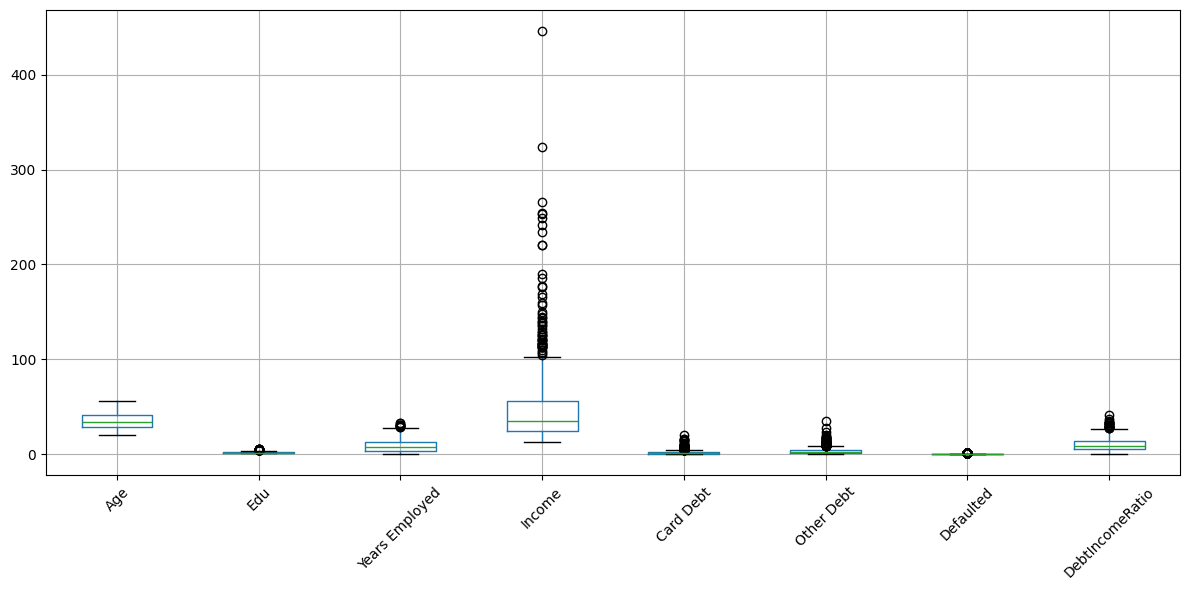

In [9]:
plt.figure(figsize=(12, 6))
X.boxplot(rot=45)
plt.tight_layout()
plt.show()


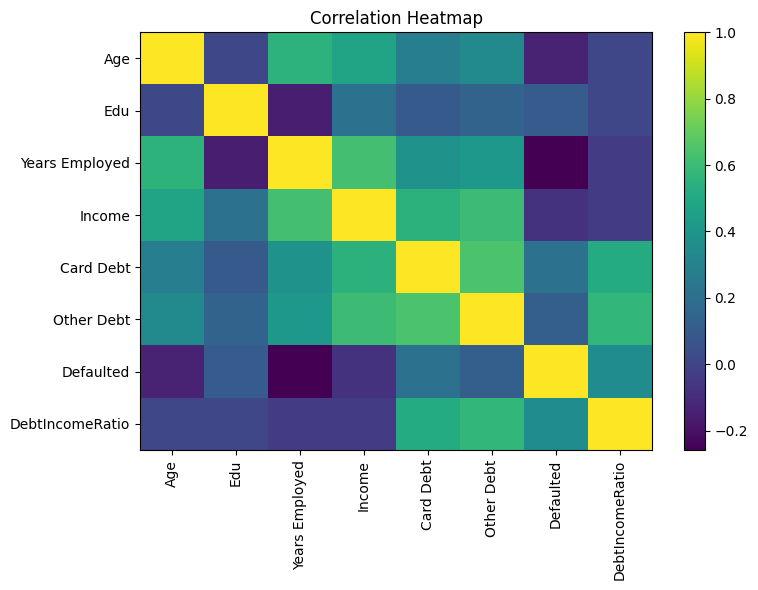

In [10]:
corr = X.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


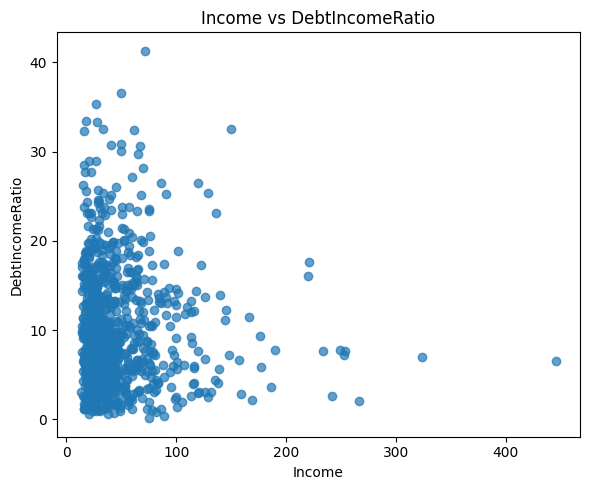

In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(X["Income"], X["DebtIncomeRatio"], alpha=0.7)
plt.xlabel("Income")
plt.ylabel("DebtIncomeRatio")
plt.title("Income vs DebtIncomeRatio")
plt.tight_layout()
plt.show()


In [12]:
X_train, X_test = train_test_split(X, test_size=0.30, random_state=42)
X_train.shape, X_test.shape


((595, 8), (255, 8))

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape


((595, 8), (255, 8))

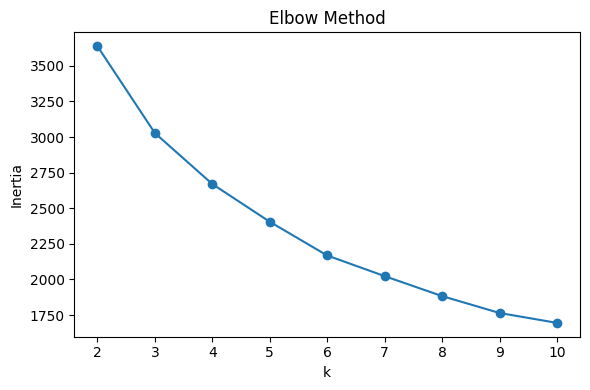

In [14]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.tight_layout()
plt.show()


In [17]:
k_chosen = 4

kmeans = KMeans(n_clusters=k_chosen, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

train_labels = kmeans.labels_
train_labels[:10]


array([1, 0, 1, 0, 0, 3, 3, 3, 3, 1], dtype=int32)

In [18]:
sil_score = silhouette_score(X_train_scaled, train_labels)
sil_score


np.float64(0.2458506230870469)

In [19]:
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(centers_original, columns=features)
centers_df


,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,32.267241,1.896552,3.836207,31.310345,1.566888,2.680000,9.913793e-01,13.848276
1,42.832168,1.517483,15.958042,68.412587,1.786140,3.893413,1.398601e-02,9.651748
2,41.047619,2.357143,15.404762,125.333333,6.085262,10.995833,2.857143e-01,17.009524
3,32.006803,1.639456,5.802721,31.190476,0.754643,1.641929,1.387779e-16,8.032993


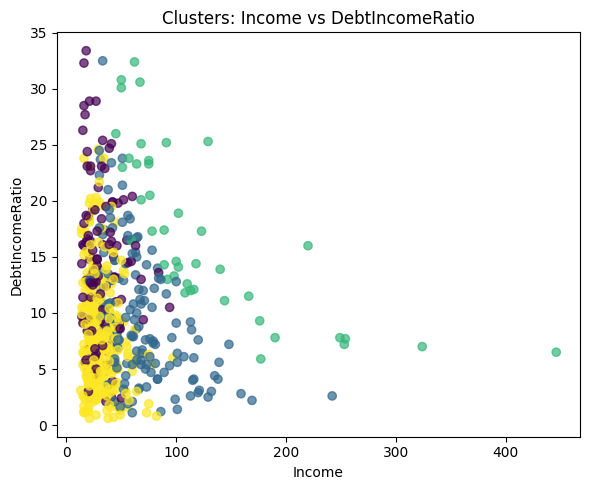

In [20]:
plt.figure(figsize=(6, 5))
plt.scatter(
    X_train["Income"],
    X_train["DebtIncomeRatio"],
    c=train_labels,
    alpha=0.7
)
plt.xlabel("Income")
plt.ylabel("DebtIncomeRatio")
plt.title("Clusters: Income vs DebtIncomeRatio")
plt.tight_layout()
plt.show()


In [21]:
print(
    "This K-Means model groups customers into segments based on similarity across age, education, employment, income, debt levels, default status, and debt to income ratio. "
    "Customers within the same cluster share similar financial and behavioral patterns, which helps describe different customer profiles without predicting a single outcome."
)


This K-Means model groups customers into segments based on similarity across age, education, employment, income, debt levels, default status, and debt to income ratio. Customers within the same cluster share similar financial and behavioral patterns, which helps describe different customer profiles without predicting a single outcome.


In [22]:
# Fix column name mismatch if needed
rename_map = {
    "YearsEmployed": "Years Employed",
    "CardDebt": "Card Debt",
    "OtherDebt": "Other Debt",
    "DebtIncome": "DebtIncomeRatio"
}
data = data.rename(columns=rename_map)


In [23]:
# Fix Defaulted if it is stored as text
if "Defaulted" in data.columns:
    data["Defaulted"] = pd.to_numeric(data["Defaulted"], errors="coerce").fillna(data["Defaulted"].mode()[0])
